# Нейросеть для предсказания калорийности блюд
## Русаков Егор

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

## Исследовательский анализ (EDA)

In [2]:
dishes = pd.read_csv('data/dish.csv')
ingredients = pd.read_csv('data/ingredients.csv')

display(dishes.head())
display(ingredients.head())

dishes.info()
ingredients.info()

print(f"Блюд: {len(dishes)}, Ингредиентов: {len(ingredients)}")

,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train


,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad
3,4,bacon
4,5,potatoes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   object 
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   object 
 4   split           3262 non-null   object 
dtypes: float64(2), object(3)
memory usage: 127.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      555 non-null    int64 
 1   ingr    555 non-null    object
dtypes: int64(1), object(1)
memory usage: 8.8+ KB
Блюд: 3262, Ингредиентов: 555


In [3]:
id_to_name = dict(zip(
    ingredients["id"].map(lambda ingredient_id: f"ingr_{ingredient_id:010d}"),
    ingredients["ingr"],
))

dishes["ingredients"] = dishes["ingredients"].map(
    lambda ids: ", ".join(id_to_name[token] for token in ids.split(";"))
)

dishes.head()

,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,"soy sauce, garlic, white rice, parsley, onions...",test
1,dish_1561662054,419.438782,292.0,"pepper, white rice, mixed greens, garlic, soy ...",train
2,dish_1562008979,382.936646,290.0,"jalapenos, lemon juice, pork, wheat berry, cab...",test
3,dish_1560455030,20.590000,103.0,"cherry tomatoes, cucumbers, baby carrots",train
4,dish_1558372433,74.360001,143.0,deprecated,train


Медиана: 209.110062, Среднее: 255.0127380726548


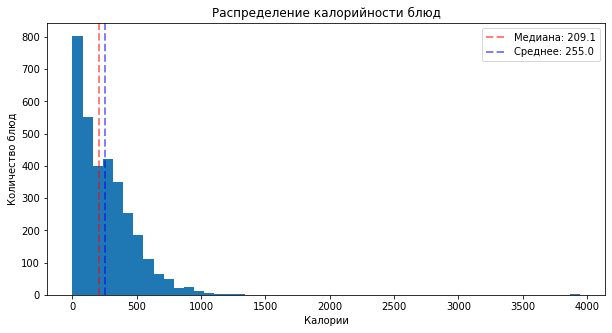

In [20]:
plt.figure(figsize=(10, 5))
plt.hist(dishes['total_calories'], bins=50)

median = dishes['total_calories'].median()
avg = dishes['total_calories'].mean()

print(f"Медиана: {median}, Среднее: {avg}")

plt.axvline(median, color='red', linestyle='--', linewidth=2, alpha=0.5, label=f'Медиана: {median:.1f}')
plt.axvline(avg, color='blue', linestyle='--', linewidth=2, alpha=0.5, label=f'Среднее: {avg:.1f}')

plt.title("Распределение калорийности блюд")
plt.xlabel("Калории")
plt.ylabel("Количество блюд")
plt.legend() 
plt.show()


В среднем коллорийность блюд составляет 255 кКал.

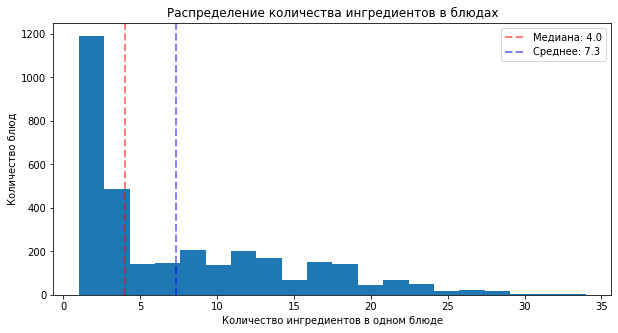

In [30]:
ingredients_count = dishes['ingredients'].str.split(',').str.len()

plt.figure(figsize=(10, 5))
plt.hist(ingredients_count, bins=20)

median = ingredients_count.median()
median = ingredients_count.median()
avg = ingredients_count.mean()

plt.axvline(median, color='red', linestyle='--', linewidth=2, alpha=0.5, label=f'Медиана: {median:.1f}')
plt.axvline(avg, color='blue', linestyle='--', linewidth=2, alpha=0.5, label=f'Среднее: {avg:.1f}')

plt.title("Распределение количества ингредиентов в блюдах")
plt.xlabel("Количество ингредиентов в одном блюде")
plt.ylabel("Количество блюд")
plt.legend()
plt.show()


В среднем в каждом блюде содержится 7 ингредиентов. Медиана равна 4.

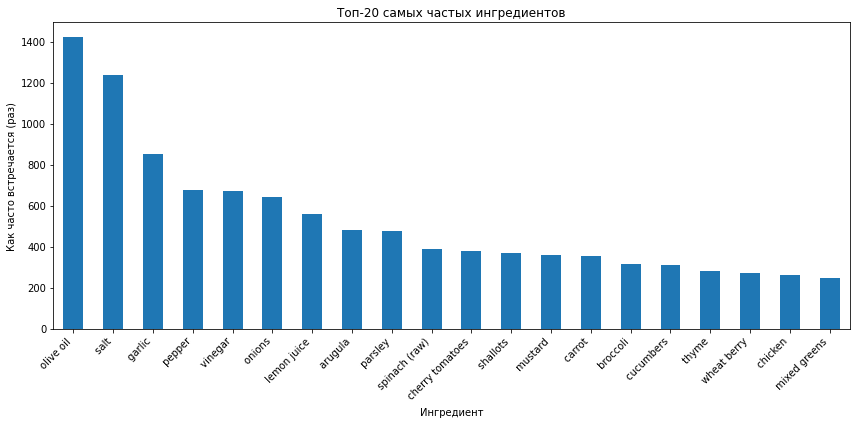

In [36]:
top_ingredients = dishes['ingredients'].str.split(',').explode().value_counts().head(20)

plt.figure(figsize=(12, 6))
top_ingredients.plot(kind='bar')

plt.title("Топ-20 самых частых ингредиентов")
plt.xlabel("Ингредиент")
plt.ylabel("Как часто встречается (раз)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


Выведен топ-20 самых частых ингредиентов, которые встречаются в блюдах.